In [699]:
from reader_util import read_file
import pandas as pd
import numpy as np
header, rows = read_file()
data_df = pd.DataFrame(rows,columns=header)
data_df.columns


Index(['', 'year', 'region', 'Annual rent sqm', 'Avg yearly inc KSEK'], dtype='str')

Text(0, 0.5, 'Annual rent sqm')

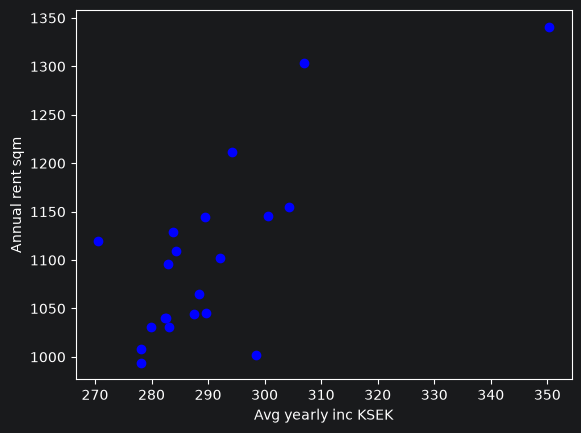

In [700]:
import matplotlib.pyplot as plt
from collections import defaultdict
plt.scatter(data_df["Avg yearly inc KSEK"], data_df["Annual rent sqm"], color="blue", label="Training data", )
plt.xlabel("Avg yearly inc KSEK")
plt.ylabel("Annual rent sqm")

In [701]:
class KMeansClassifier:
    def __init__(self, k, max_iter, seed):
        self.k = k
        self.max_iter = max_iter
        self.rng = np.random.RandomState(seed)
        self.labels = None

    @staticmethod
    def euclidean_distance(point, centroid):
        return np.sqrt(np.sum((point-centroid)**2))

    def fit(self, features: np.typing.NDArray):
        features = np.asarray(features, dtype=float)

        indices = self.rng.choice(len(features), self.k, replace=False)
        clusters = { i :{"centroid": features[idx], "points": []}for i , idx in enumerate(indices)}
        for i in range(self.max_iter):
            # Clear the points before running
            for cluster in clusters.values():
                cluster["points"] = []

            self.labels = []
            for row in features:
                distances = {cluster_id: self.euclidean_distance(row, cluster["centroid"]) for cluster_id, cluster in clusters.items()}
                nearest_id = min(distances, key=distances.get)
                clusters[nearest_id]["points"].append(row)
                self.labels.append(nearest_id)
            # Move each center to the mean of its points
            converged = True
            for cluster in clusters.values():
                if not cluster["points"]:
                    continue  # empty cluster: keep old center
                new_center = np.mean(cluster["points"], axis=0)
                if not np.allclose(new_center, cluster["centroid"]):
                    converged = False
                cluster["centroid"] = new_center
            if converged:
                break
        self.centroids = np.array([c["centroid"] for c in clusters.values()])
        self.labels = np.array(self.labels)
        return self
    def predict(self, new_points):
        if self.centroids is None:
            raise RuntimeError("Call fit() before predict().")
        distances = np.linalg.norm(new_points[:, np.newaxis] - self.centroids, axis=2)
        return dists.argmin(axis=1), distances



Text(0, 0.5, 'Annual rent sqm')

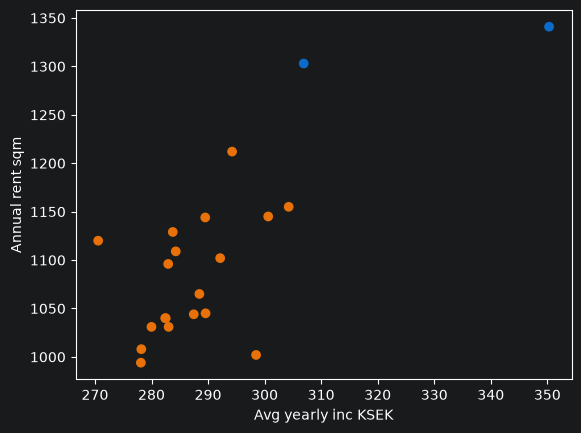

In [702]:
X = data_df[["Avg yearly inc KSEK", "Annual rent sqm"]].to_numpy()
mean = X.mean(axis=0)
std = X.std(axis=0)
X_scaled = (X - mean) / std
data_df["cluster"] = KMeansClassifier(k=2, max_iter=10, seed=42).fit(X_scaled).labels
bg = {0: "#0b6bcb", 1: "#e8710a"}
data_df["color"] = data_df["cluster"].map(bg)
plt.scatter(data_df["Avg yearly inc KSEK"], data_df["Annual rent sqm"], c=data_df["color"], )
plt.xlabel("Avg yearly inc KSEK")
plt.ylabel("Annual rent sqm")


In [703]:
def silhouette_score(_X, labels) -> float:
    """Calculate silhouette for k-means cluster."""
    clusters = {c: _X[labels == c] for c in np.unique(labels)}
    if not 2 <= len(clusters) <= len(X) - 1:
        return np.nan
    s_scores = []
    for cluster, points in clusters.items():
        for point in points:
            if len(points) == 1:
                s_scores.append(0.0)
                continue
            a = np.linalg.norm(points - point, axis=1).sum() / (len(points) - 1)
            b = min(np.linalg.norm(other - point, axis=1).mean()
                    for oc, other in clusters.items() if oc != cluster)
            s_scores.append((b - a) / max(a, b))
    return np.mean(s_scores)

In [704]:
k_values = range(2, 11)
silhouette_scores = []
for k in k_values:
    labels = KMeansClassifier(k=k, max_iter=100, seed=42).fit(X_scaled).labels
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
optimal_k = k_values[np.argmax(silhouette_scores)]
optimal_k

2

In [705]:
## Sanity check
from sklearn.cluster import KMeans
from  sklearn.metrics import silhouette_score as _silhouette_score
pro_model = KMeans(n_clusters=2, n_init=100, random_state=42) # sanity check
pro_model.fit(X_scaled)
print( pro_model.labels_)
print(_silhouette_score(X_scaled,pro_model.labels_))

our_labels = KMeansClassifier(k=2, max_iter=100, seed=42).fit(X_scaled).labels
score = silhouette_score(X_scaled, our_labels)
print(our_labels)
print(score)

[1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
0.661059573784138
[0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
0.661059573784138


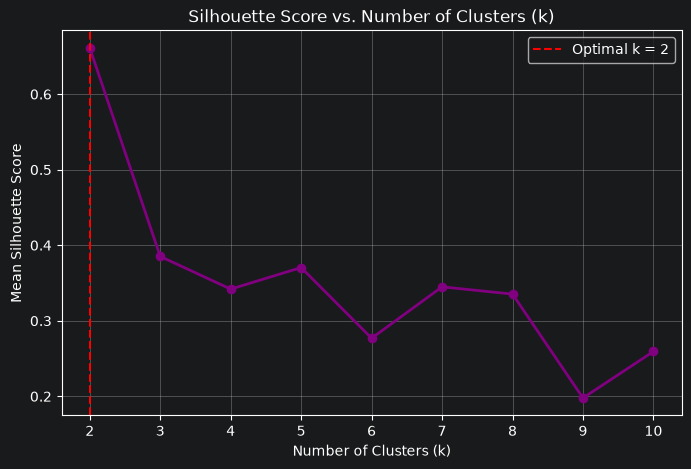

In [706]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', color='purple', linestyle='-', linewidth=2)
plt.title("Silhouette Score vs. Number of Clusters (k)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Mean Silhouette Score")
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
plt.grid(True)
plt.legend()
plt.show()

In [707]:
model = KMeansClassifier(k=2, max_iter=100, seed=42).fit(X_scaled)
new_points = np.array([[1010, 320.12],
                       [1258, 320.0],
                       [980,  292.4]])
mean = new_points.mean(axis=0)
std = new_points.std(axis=0)
new_points_scaled = (new_points - mean) / std
new_labels, dists = model.predict(new_points_scaled)
new_labels, dists

(array([1, 1, 1]),
 array([[3.40116783, 1.02211725],
        [1.95910163, 1.91236606],
        [4.97992191, 1.29504529]]))

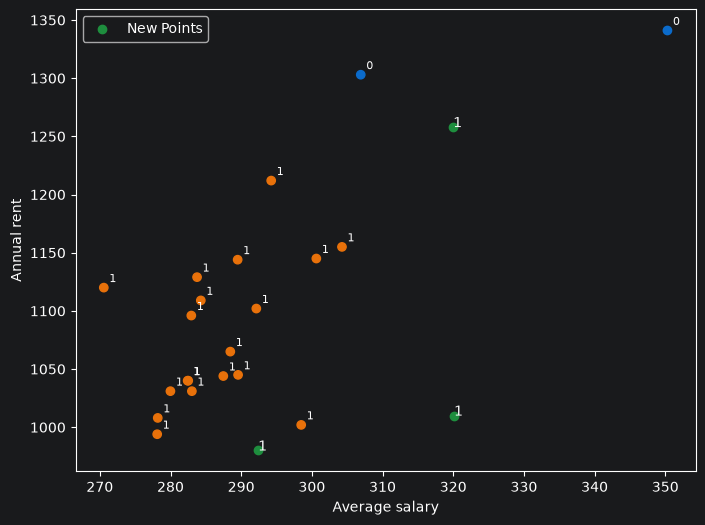

In [708]:
_, ax = plt.subplots(figsize=(8, 6))
bg = {0: "#0b6bcb", 1: "#e8710a"}
for _, row in data_df.iterrows():
    ax.annotate(row["cluster"], (row["Avg yearly inc KSEK"], row["Annual rent sqm"]),
                xytext=(4, 4), textcoords="offset points", fontsize=8)
for label, new_point in zip(new_labels, new_points):
    ax.annotate(label, (new_point[1], new_point[0]),)
data_df["color"] = data_df["cluster"].map(bg)

ax.scatter(data_df["Avg yearly inc KSEK"], data_df["Annual rent sqm"], c=data_df["color"])
ax.scatter(new_points[:, 1], new_points[:, 0], label="New Points", c="#1e8e3e")
ax.set_xlabel("Average salary")
ax.set_ylabel("Annual rent")
ax.legend()
plt.show()